In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import sunspots

data = sunspots.load_pandas().data
data["YEAR"] = pd.to_datetime(data["YEAR"], format="%Y")
data = data.set_index("YEAR")

print(data.head())

            SUNACTIVITY
YEAR                   
1700-01-01          5.0
1701-01-01         11.0
1702-01-01         16.0
1703-01-01         23.0
1704-01-01         36.0


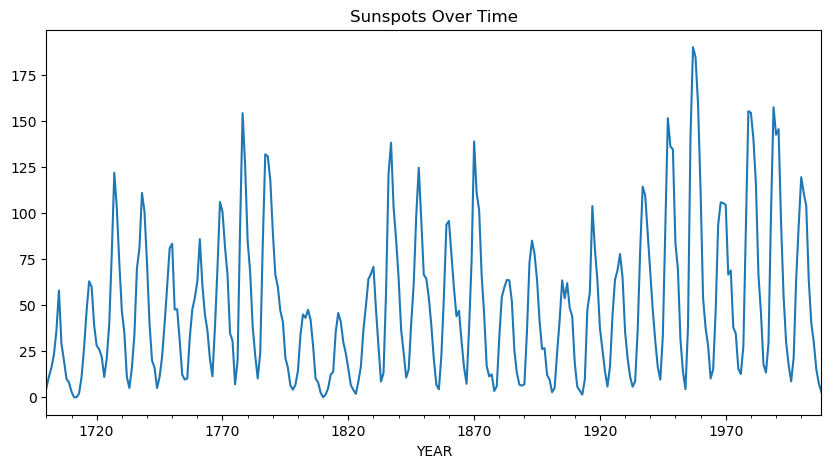

In [2]:
data["SUNACTIVITY"].plot(figsize=(10,5), title="Sunspots Over Time")
plt.show()

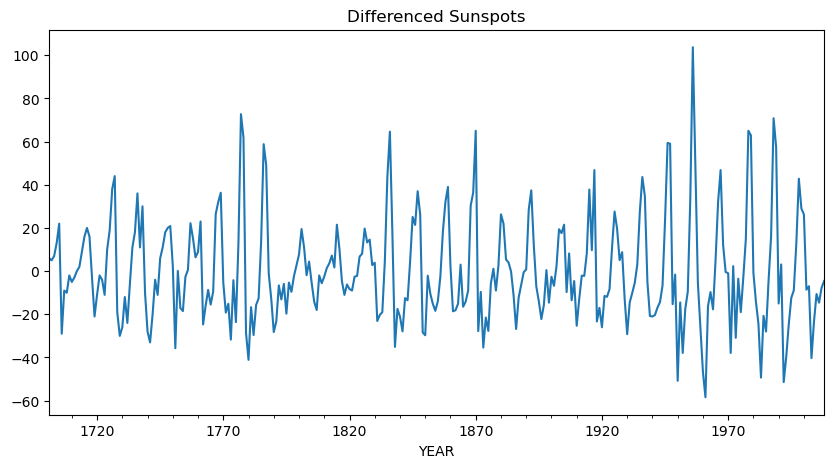

In [3]:
data["diff"] = data["SUNACTIVITY"].diff()
data["diff"].dropna().plot(figsize=(10,5), title="Differenced Sunspots")
plt.show()

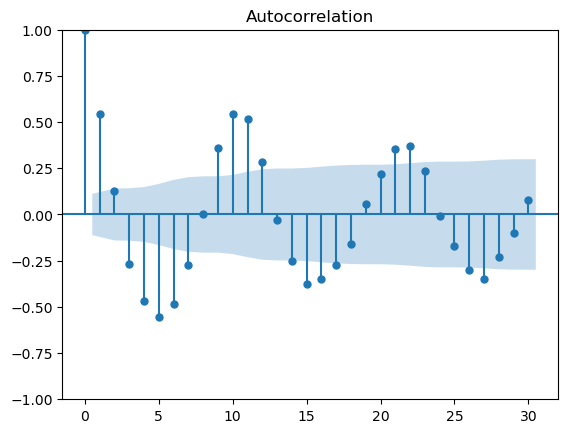

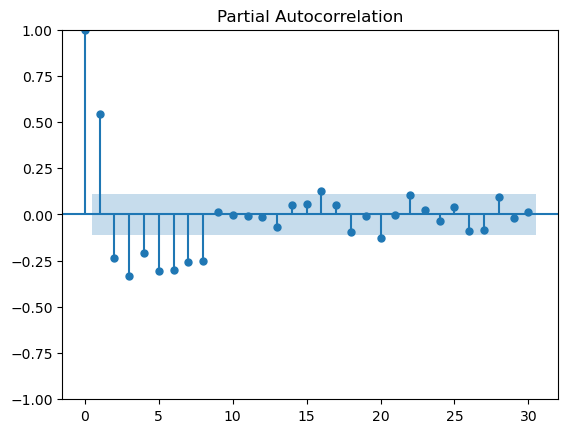

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data["diff"].dropna(), lags=30)
plot_pacf(data["diff"].dropna(), lags=30)
plt.show()

In [6]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data["diff"].dropna(), order=(2,0,1))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\PYTHON\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible 

                               SARIMAX Results                                
Dep. Variable:                   diff   No. Observations:                  308
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -1301.000
Date:                Thu, 23 Apr 2026   AIC                           2611.999
Time:                        12:15:03   BIC                           2630.650
Sample:                    01-01-1701   HQIC                          2619.457
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1192      0.173      0.691      0.490      -0.219       0.458
ar.L1          1.3714      0.037     37.251      0.000       1.299       1.444
ar.L2         -0.7064      0.036    -19.818      0.0

In [7]:
forecast = model_fit.predict(
    start=len(data["diff"].dropna()),
    end=len(data["diff"].dropna())+10
)

print(forecast)

2009-01-01    17.629274
2010-01-01    27.465823
2011-01-01    25.252605
2012-01-01    15.268862
2013-01-01     3.140796
2014-01-01    -6.438818
2015-01-01   -11.008780
2016-01-01   -10.508847
2017-01-01    -6.595010
2018-01-01    -1.580811
2019-01-01     2.530804
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [8]:
last_value = data["SUNACTIVITY"].iloc[-1]

forecast_original = last_value + forecast.cumsum()

print(forecast_original)

2009-01-01    20.529274
2010-01-01    47.995097
2011-01-01    73.247702
2012-01-01    88.516564
2013-01-01    91.657359
2014-01-01    85.218541
2015-01-01    74.209761
2016-01-01    63.700914
2017-01-01    57.105904
2018-01-01    55.525093
2019-01-01    58.055897
Freq: YS-JAN, Name: predicted_mean, dtype: float64


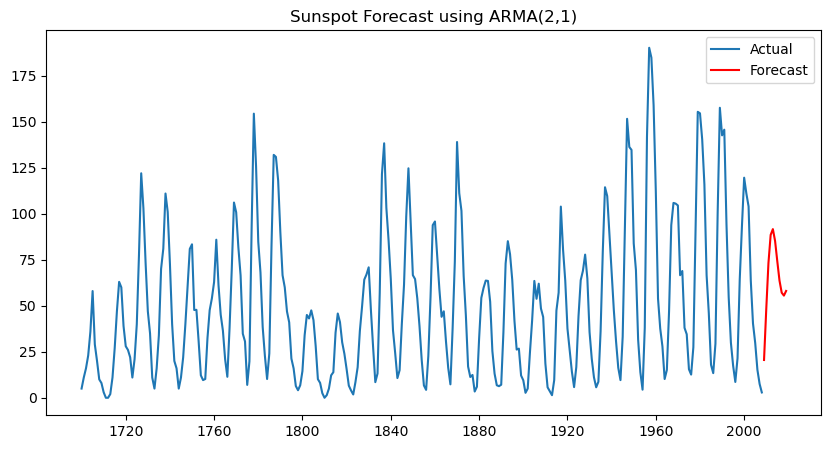

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data["SUNACTIVITY"], label="Actual")

plt.plot(forecast_original.index, forecast_original, label="Forecast", color="red")

plt.legend()
plt.title("Sunspot Forecast using ARMA(2,1)")
plt.show()